# Name -PRABAL GHOSH

## DATASET =  breast_metabolomics.csv

### LAB - OMICS 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline




In [2]:
df = pd.read_csv("breast_metabolomics.csv")
df.head()

,Label,1-hexadecanol,1-monostearin,"1,2,4-benzenetriol","1,5-anhydroglucitol",2-aminoadipic acid,2-hydroxybutanoic acid,2-hydroxyglutaric acid,2-hydroxyvaleric acid,2-ketoadipic acid,...,trehalose,tryptophan,tyrosine,uracil,urea,uric acid,uridine,uridine-5'-monophosphate,valine,xanthine
0,0,11.112099,9.907075,11.093423,14.241355,11.218484,13.902791,12.234127,14.627043,12.729476,...,13.176623,13.820936,16.940040,15.026577,17.861534,12.452281,8.127786,7.367381,17.127506,8.944028
1,0,11.658437,10.598369,11.993399,12.298942,10.547373,14.436735,13.568694,16.712891,13.405477,...,11.458791,13.027484,15.605371,14.627023,18.212003,12.266689,9.380577,7.969552,16.409022,8.477699
2,0,10.390127,9.326581,11.281837,13.564650,10.040969,14.128271,15.332380,15.050071,12.108104,...,11.289519,13.855135,16.900707,16.274211,18.011109,13.129556,11.453729,8.158895,17.509767,12.609300
3,0,12.160193,10.918137,12.934515,15.019961,8.797349,15.122361,12.440414,17.579449,14.190136,...,13.753774,13.158752,15.397058,13.580863,18.480319,13.200915,8.236881,8.414879,16.993555,9.401940
4,0,10.185206,9.069104,12.949058,13.842015,10.764847,14.633731,13.155491,14.434416,12.115098,...,11.772042,14.174385,16.745180,15.973334,19.110742,14.444388,11.928346,7.679578,17.874280,9.202908


In [3]:
X = df.drop(columns=["Label"])
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
from collections import Counter

class_counts = Counter(y)
print(class_counts)


Counter({1: 204, 0: 67})


<Axes: title={'center': 'Class Distribution'}, xlabel='Label'>

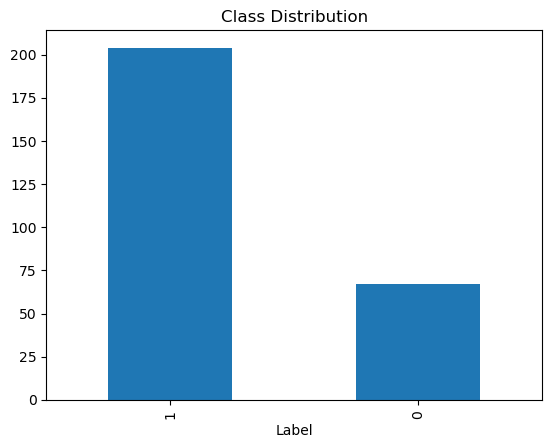

In [5]:
import pandas as pd
pd.Series(y).value_counts().plot(kind='bar', title='Class Distribution')


In [6]:
total_samples = len(y)
for label, count in class_counts.items():
    print(f'Class {label}: {count/total_samples:.2%}')


Class 0: 24.72%
Class 1: 75.28%


## Feature Selection Methods:

###  Calculate information gain

In [7]:
from sklearn.feature_selection import mutual_info_classif

info_gain = mutual_info_classif(X_train_scaled, y_train)
selected_features_info_gain = X.columns[info_gain > 0.01]  # Threshold for selection

print(selected_features_info_gain)

Index(['1-hexadecanol', '1,5-anhydroglucitol', '2-hydroxyglutaric acid',
       '2-hydroxyvaleric acid', '2-ketoglucose dimethylacetal NIST',
       '2-oxogluconic acid NIST', '3-phosphoglycerate', '4-hydroxybenzoate',
       '5'-deoxy-5'-methylthioadenosine', 'adenine', 'adipic acid', 'alanine',
       'asparagine', 'benzoic acid', 'beta-alanine', 'citric acid', 'cysteine',
       'cysteine-glycine', 'cystine', 'cytidine-5-monophosphate NIST',
       'dehydroascorbate', 'dodecanol', 'FAD', 'fructose', 'fumaric acid',
       'glucose', 'glucuronic acid', 'glutamic acid', 'glutamine',
       'glyceric acid', 'glycerol', 'glycerol-alpha-phosphate',
       'glycerol-beta-phosphate', 'glycine', 'glycolic acid', 'guanine',
       'hydroxylamine', 'hypoxanthine', 'idonic acid NIST', 'inosine',
       'inositol-4-monophosphate', 'inositol allo-', 'isothreonic acid',
       'levoglucosan', 'lysine', 'lyxitol', 'malate', 'maltotriose',
       'monopalmitin-1-glyceride', 'N-acetyl-D-mannosamine'

### Select top 100 features using ANOVA F-value

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif


selector_kbest = SelectKBest(score_func=f_classif, k=100)
X_train_kbest = selector_kbest.fit_transform(X_train_scaled, y_train)
X_test_kbest = selector_kbest.transform(X_test_scaled)

selected_features_kbest = X.columns[selector_kbest.get_support()]
print(selected_features_kbest)

Index(['1-hexadecanol', '1-monostearin', '1,2,4-benzenetriol',
       '2-aminoadipic acid', '2-hydroxybutanoic acid',
       '2-hydroxyglutaric acid', '2-hydroxyvaleric acid', '2-ketoadipic acid',
       '3-phosphoglycerate', '4-hydroxybenzoate',
       '5'-deoxy-5'-methylthioadenosine', 'abietic acid', 'adenine', 'alanine',
       'alpha ketoglutaric acid', 'aminomalonate', 'arachidonic acid',
       'arginine + ornithine', 'asparagine', 'azelaic acid', 'benzoic acid',
       'benzylalcohol', 'beta-alanine', 'capric acid', 'citric acid',
       'citrulline', 'conduritol-beta-epoxide', 'creatinine', 'cysteine',
       'cysteine-glycine', 'cystine', 'cytidine-5-monophosphate NIST',
       'dihydroabietic acid', 'dodecanol', 'fumaric acid', 'gluconic acid',
       'glucose', 'glucose-6-phosphate', 'glucuronic acid', 'glutamic acid',
       'glutamine', 'glutathione', 'glyceric acid', 'glycerol',
       'glycerol-alpha-phosphate', 'glycerol-beta-phosphate', 'glycine',
       'glycolic aci

In [44]:
# X_train_kbest

### Recursive feature elimination

In [10]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

#  RFE with Random Forest
rfe = RFE(estimator=RandomForestClassifier(), n_features_to_select=20)
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)
selected_features_rfe = X.columns[rfe.support_]
print(selected_features_rfe)

Index(['2-hydroxyglutaric acid', '3-phosphoglycerate', 'arachidonic acid',
       'beta-alanine', 'citrulline', 'creatinine',
       'cytidine-5-monophosphate NIST', 'dodecanol', 'gluconic acid',
       'glutamic acid', 'glutamine', 'idonic acid NIST', 'maltose',
       'monopalmitin-1-glyceride', 'nicotinamide', 'threonic acid', 'tyrosine',
       'uracil', 'uridine-5'-monophosphate', 'xanthine'],
      dtype='object')


### missing value ratio

In [11]:
missing_ratio = X.isnull().mean()
print(missing_ratio)
selected_features_missing_ratio = X.columns[missing_ratio < 0.1]  # Threshold for selection
print(selected_features_missing_ratio)

1-hexadecanol               0.0
1-monostearin               0.0
1,2,4-benzenetriol          0.0
1,5-anhydroglucitol         0.0
2-aminoadipic acid          0.0
                           ... 
uric acid                   0.0
uridine                     0.0
uridine-5'-monophosphate    0.0
valine                      0.0
xanthine                    0.0
Length: 162, dtype: float64
Index(['1-hexadecanol', '1-monostearin', '1,2,4-benzenetriol',
       '1,5-anhydroglucitol', '2-aminoadipic acid', '2-hydroxybutanoic acid',
       '2-hydroxyglutaric acid', '2-hydroxyvaleric acid', '2-ketoadipic acid',
       '2-ketoglucose dimethylacetal NIST',
       ...
       'trehalose', 'tryptophan', 'tyrosine', 'uracil', 'urea', 'uric acid',
       'uridine', 'uridine-5'-monophosphate', 'valine', 'xanthine'],
      dtype='object', length=162)


### Forward Selection

In [12]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

# Forward selection with Logistic Regression
forward_selector = SequentialFeatureSelector(
    LogisticRegression(), direction="forward", n_features_to_select=20
)
X_train_forward = forward_selector.fit_transform(X_train_scaled, y_train)
X_test_forward = forward_selector.transform(X_test_scaled)
selected_features_forward = X.columns[forward_selector.get_support()]
print(selected_features_forward)

Index(['1,2,4-benzenetriol', '1,5-anhydroglucitol',
       '2-ketoglucose dimethylacetal NIST', 'alpha ketoglutaric acid',
       'behenic acid', 'beta-alanine', 'cholesterol', 'citric acid',
       'creatinine', 'erythronic acid lactone', 'ethanolamine', 'FAD',
       'gluconic acid', 'guanosine', 'inositol-4-monophosphate',
       'inositol allo-', 'linoleic acid', 'phosphoethanolamine', 'sorbitol',
       'xanthine'],
      dtype='object')


### L1 Regularization (Lasso)

In [13]:
from sklearn.linear_model import LassoCV

# Train Lasso to select features
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)
selected_features_lasso = X.columns[lasso.coef_ != 0]
X_train_lasso = X_train_scaled[:, lasso.coef_ != 0]
X_test_lasso = X_test_scaled[:, lasso.coef_ != 0]


C:\Users\praba\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.003732402004632984, tolerance: 0.003069767441860464
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\praba\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.006290592103508352, tolerance: 0.003069767441860464
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\praba\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.007211202934150007, tolerance: 0.003069767441860464
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\praba\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_

C:\Users\praba\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.003935045929899905, tolerance: 0.0032809248554913303
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\praba\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.003777790005385473, tolerance: 0.0032809248554913303
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\praba\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.00460289637788458, tolerance: 0.0032809248554913303
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\praba\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinat

In [14]:
print(selected_features_lasso)

Index(['3-phosphoglycerate', 'aspartic acid', 'beta-alanine', 'creatinine',
       'cytidine-5-monophosphate NIST', 'fumaric acid', 'glutamic acid',
       'glutamine', 'glutathione', 'isothreonic acid',
       'N-acetyl-D-mannosamine', 'N-methylalanine', 'nicotinamide',
       'oxalic acid', 'proline', 'taurine', 'trehalose', 'tyrosine', 'uracil',
       'uridine-5'-monophosphate', 'xanthine'],
      dtype='object')


## Feature Extraction Methods:

### PCA

In [15]:
from sklearn.decomposition import PCA

pca_model = PCA(n_components=0.90, svd_solver='full')
X_train_pca = pca_model.fit_transform(X_train_scaled)
X_test_pca = pca_model.transform(X_test_scaled)



In [16]:
X_train_pca.shape, X_test_pca.shape

((216, 59), (55, 59))

In [17]:
pca_model.explained_variance_ratio_


array([0.16849054, 0.09575458, 0.05467561, 0.03725222, 0.03299838,
       0.03131157, 0.02611338, 0.02442912, 0.02143196, 0.02110579,
       0.01931459, 0.0188498 , 0.01600131, 0.01496005, 0.01443402,
       0.01327706, 0.01311847, 0.01300535, 0.01147839, 0.01141784,
       0.01106788, 0.01062535, 0.00968004, 0.00952216, 0.00923378,
       0.00880361, 0.00863605, 0.00848509, 0.00804169, 0.00797039,
       0.00790863, 0.00764565, 0.00742906, 0.00717819, 0.00672789,
       0.00649629, 0.00630624, 0.00626252, 0.00596524, 0.00579212,
       0.00565851, 0.00554778, 0.00538892, 0.00511728, 0.0049612 ,
       0.00488251, 0.00468655, 0.00457057, 0.0044248 , 0.0042542 ,
       0.00409682, 0.00403034, 0.00388304, 0.00376278, 0.00371703,
       0.00348755, 0.00347004, 0.00344735, 0.00324415])

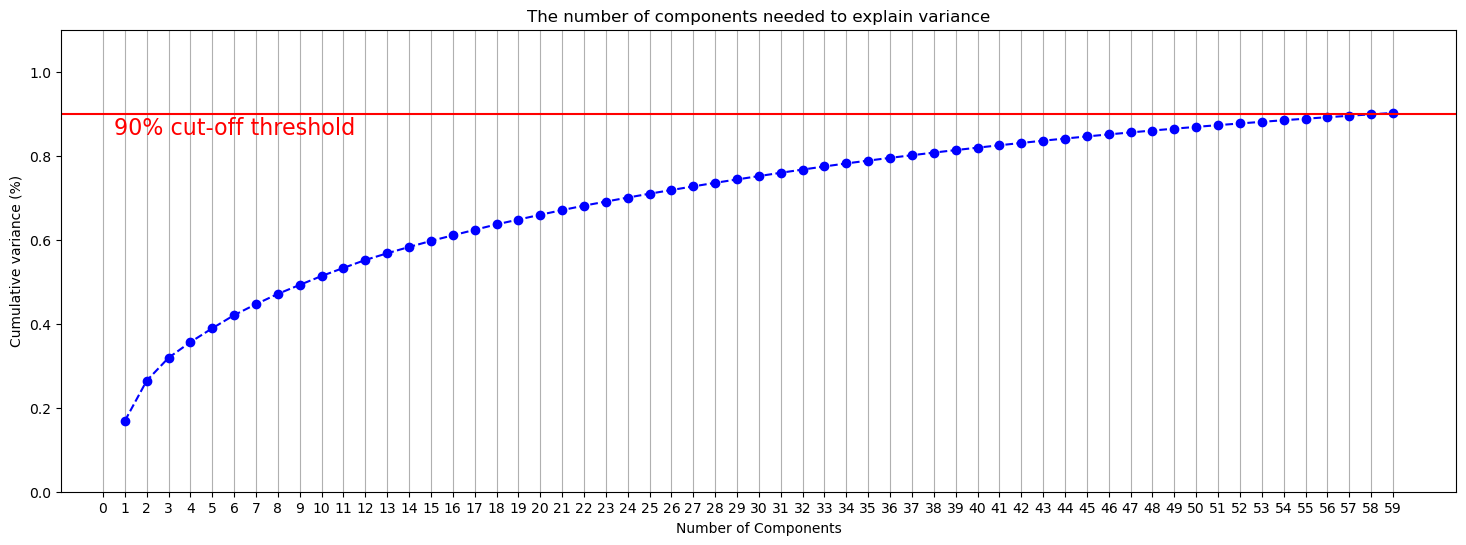

In [18]:
# % matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (18,6)

fig, ax = plt.subplots()
xi = np.arange(1, 60, step=1)   #  X_train_pca.shape =(216, 59) thats why  1 am using 1 to 216
y = np.cumsum(pca_model.explained_variance_ratio_)

plt.ylim(0.0,1.1)
plt.plot(xi, y, marker='o', linestyle='--', color='b')

plt.xlabel('Number of Components')
plt.xticks(np.arange(0, 60, step=1)) #change from 0-based array index to 1-based human-readable label
plt.ylabel('Cumulative variance (%)')
plt.title('The number of components needed to explain variance')

plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(0.5, 0.85, '90% cut-off threshold', color = 'red', fontsize=16)

ax.grid(axis='x')
plt.show()

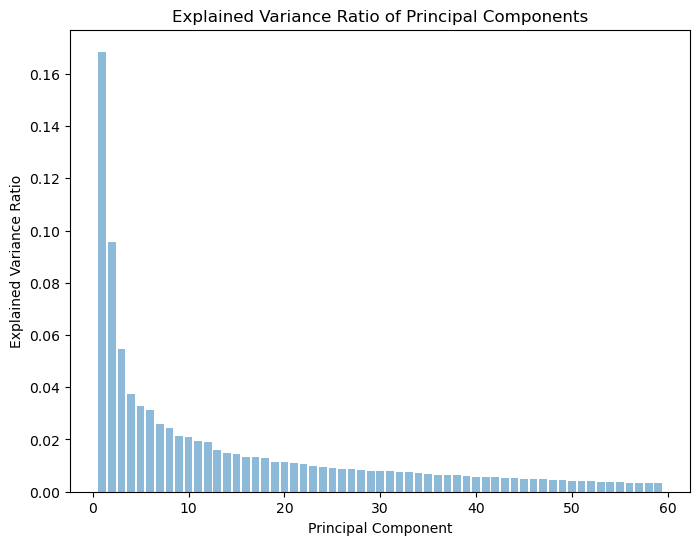

In [19]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.preprocessing import StandardScaler

# pca_model.plot(figsize=(10,8))
# plt.show()


# Plotting the explained variance ratio
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(pca_model.explained_variance_ratio_) + 1), pca_model.explained_variance_ratio_, alpha=0.5, align='center')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of Principal Components')
plt.show()

In [20]:
explained_variance = pca_model.explained_variance_ratio_
singular_values = pca_model.singular_values_

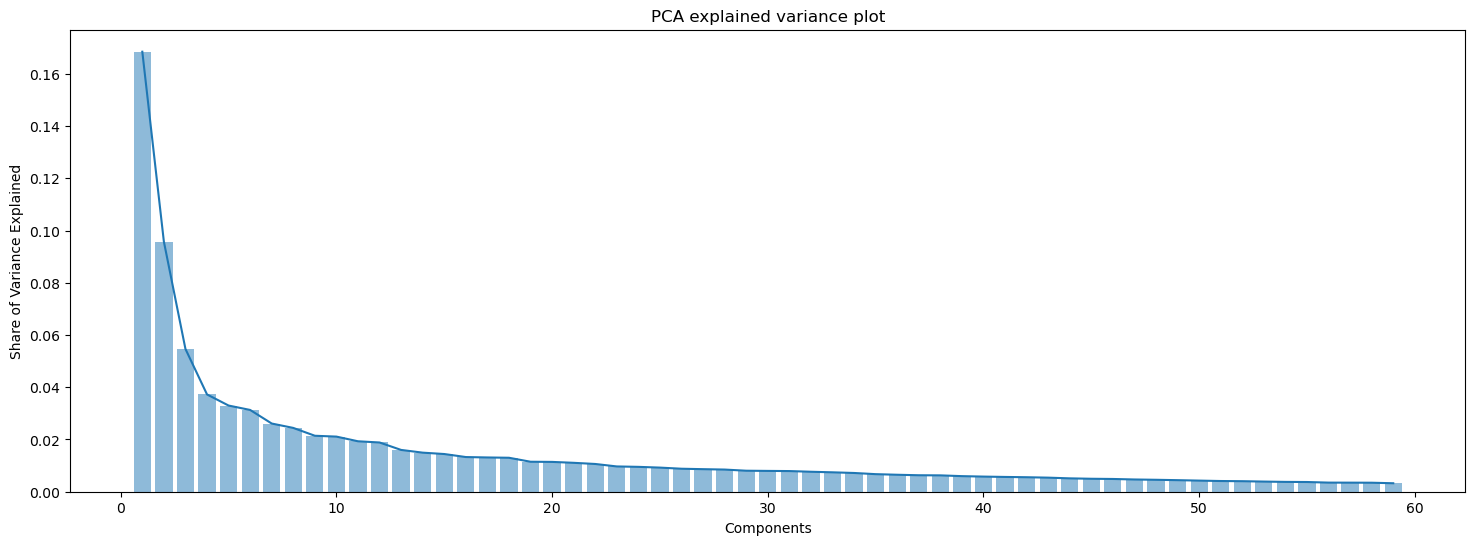

In [21]:
x = np.arange(1,len(explained_variance)+1)
plt.bar(range(1, len(pca_model.explained_variance_ratio_) + 1), pca_model.explained_variance_ratio_, alpha=0.5, align='center')

plt.plot(x, explained_variance)
plt.ylabel('Share of Variance Explained')
plt.title("PCA explained variance plot")
plt.xlabel("Components")
plt.show()

In [22]:
for i in range(0, 59):
    print(f"Component {i:>2} accounts for {explained_variance[i]*100:>2.2f}% of variance")

Component  0 accounts for 16.85% of variance
Component  1 accounts for 9.58% of variance
Component  2 accounts for 5.47% of variance
Component  3 accounts for 3.73% of variance
Component  4 accounts for 3.30% of variance
Component  5 accounts for 3.13% of variance
Component  6 accounts for 2.61% of variance
Component  7 accounts for 2.44% of variance
Component  8 accounts for 2.14% of variance
Component  9 accounts for 2.11% of variance
Component 10 accounts for 1.93% of variance
Component 11 accounts for 1.88% of variance
Component 12 accounts for 1.60% of variance
Component 13 accounts for 1.50% of variance
Component 14 accounts for 1.44% of variance
Component 15 accounts for 1.33% of variance
Component 16 accounts for 1.31% of variance
Component 17 accounts for 1.30% of variance
Component 18 accounts for 1.15% of variance
Component 19 accounts for 1.14% of variance
Component 20 accounts for 1.11% of variance
Component 21 accounts for 1.06% of variance
Component 22 accounts for 0.97%

In [23]:
# import seaborn as sns

# # PCA Plot
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], c=y_train, cmap='jet', alpha=0.7)
# plt.title("PCA Visualization")
# plt.show()


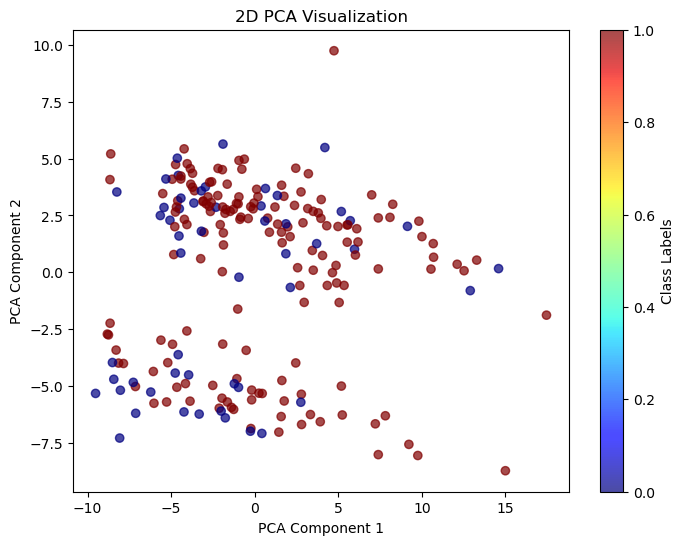

In [24]:
plt.figure(figsize=(8,6))
# plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y, cmap='jet', alpha=0.7)
plt.scatter(x=X_train_pca[:, 0], y=X_train_pca[:, 1], c=y_train, cmap='jet', alpha=0.7)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("2D PCA Visualization")
plt.colorbar(label="Class Labels")
plt.show()



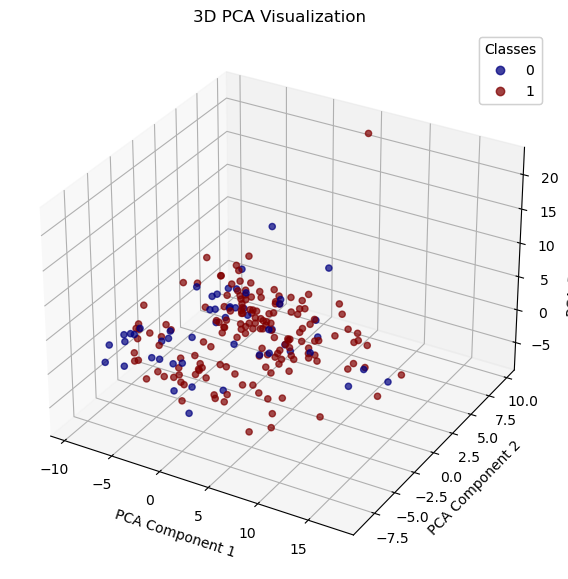

In [25]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_train, cmap='jet', alpha=0.7)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D PCA Visualization")

# Add legend
legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)

plt.show()

####  For large datasets, first reduce dimensions with PCA before applying t-SNE ( if X has many features):


In [26]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train_pca)

Text(0.5, 1.0, 't-SNE on PCA')

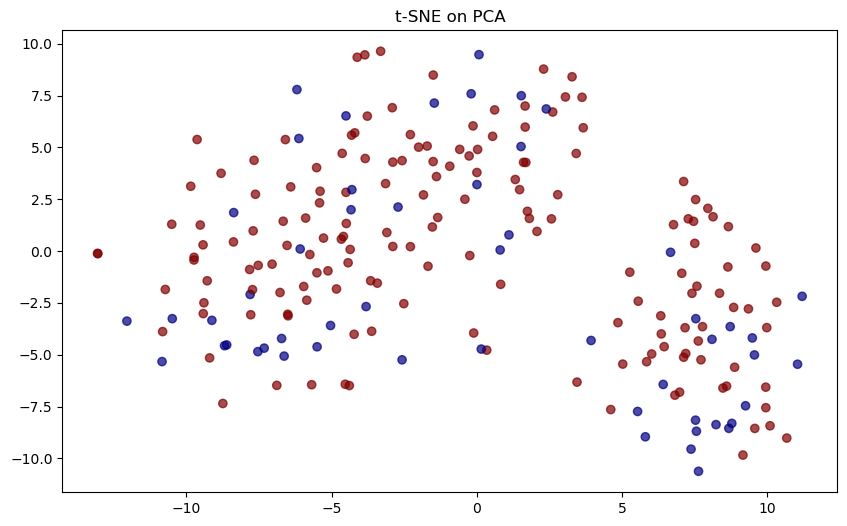

In [27]:
plt.figure(figsize=(10, 6))

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='jet', alpha=0.7)
plt.title('t-SNE on PCA')


In [28]:
# t-SNE
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(X_train_pca)

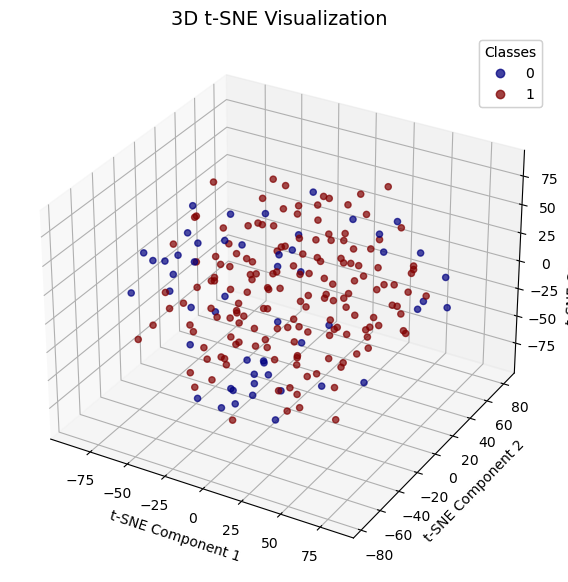

In [29]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=y_train, cmap='jet', alpha=0.7)

ax.set_title("3D t-SNE Visualization", fontsize=14)
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_zlabel("t-SNE Component 3")

legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)
plt.show()


In [30]:
# from sklearn.mixture import GaussianMixture

# gmm = GaussianMixture(n_components=10, random_state=42)
# gmm.fit(X_train_scaled)
# X_train_mppca = gmm.predict_proba(X_train_scaled)
# X_test_mppca = gmm.predict_proba(X_test_scaled)

C:\Users\praba\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Kernel PCA


In [31]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(n_components=10, kernel="rbf", random_state=42)
X_train_kpca = kpca.fit_transform(X_train_scaled)
X_test_kpca = kpca.transform(X_test_scaled)

In [32]:
# plt.scatter(X_train_kpca[:, 0], X_train_kpca[:, 1], c=y_train, cmap='jet', alpha=0.7)
# plt.title('Kernel PCA')

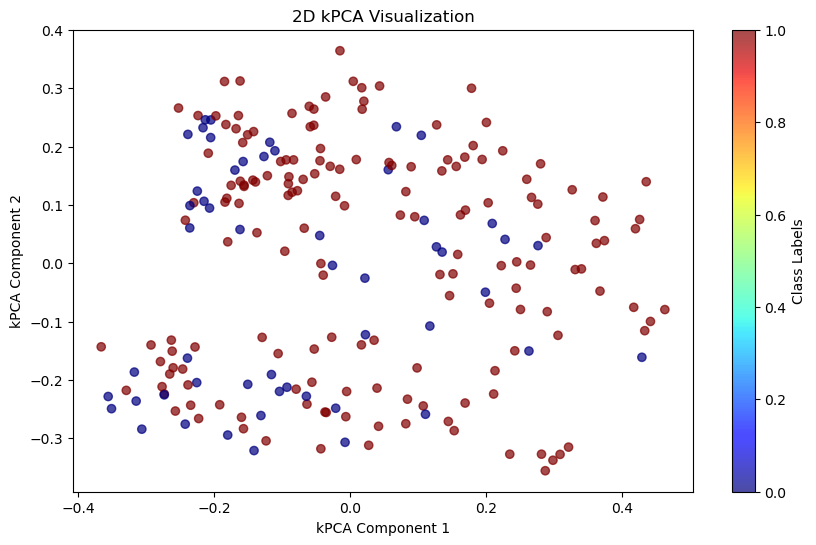

In [33]:
plt.figure(figsize=(10, 6))

plt.scatter(x=X_train_kpca[:, 0], y=X_train_kpca[:, 1], c=y_train, cmap='jet', alpha=0.7)


plt.xlabel("kPCA Component 1")
plt.ylabel("kPCA Component 2")
plt.title("2D kPCA Visualization")
plt.colorbar(label="Class Labels")
plt.show()



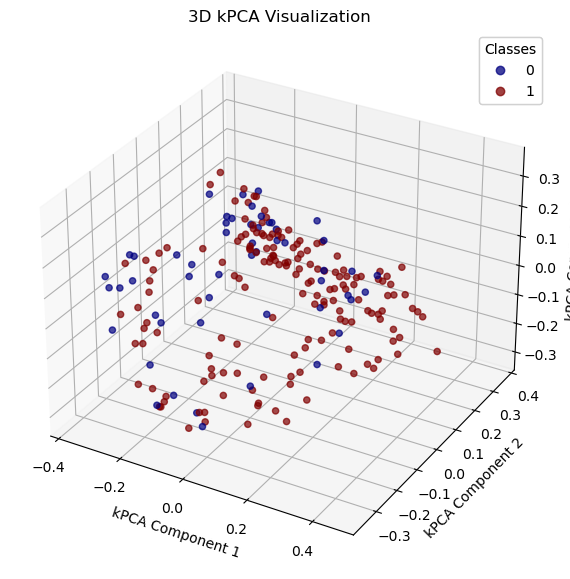

In [34]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_train_kpca[:, 0], X_train_kpca[:, 1], X_train_kpca[:, 2], c=y_train, cmap='jet', alpha=0.7)

ax.set_xlabel("kPCA Component 1")
ax.set_ylabel("kPCA Component 2")
ax.set_zlabel("kPCA Component 3")
ax.set_title("3D kPCA Visualization")

legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)

plt.show()

####  For large datasets, first reduce dimensions with PCA before applying t-SNE ( if X has many features):


In [35]:

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train_kpca)

In [36]:
# plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='jet', alpha=0.7)
# plt.title('t-SNE')


Text(0.5, 1.0, 't-SNE on Kernel PCA')

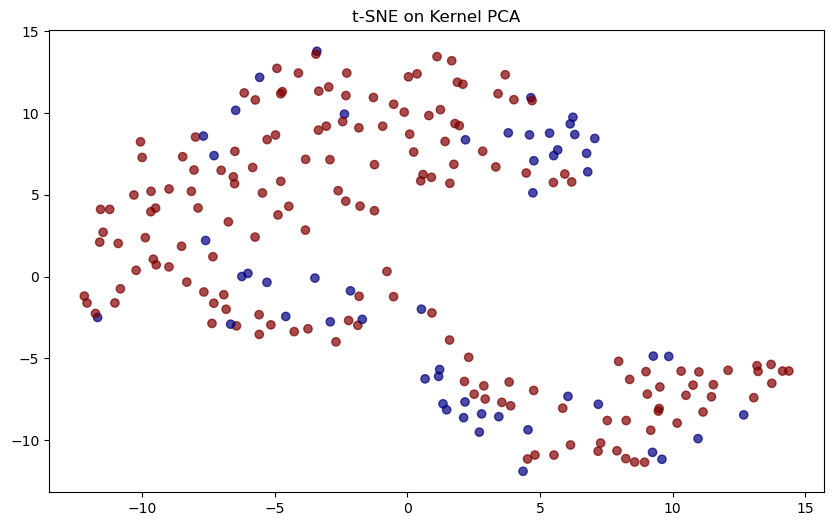

In [37]:
plt.figure(figsize=(10, 6))

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='jet', alpha=0.7)
plt.title('t-SNE on Kernel PCA')


In [38]:
# t-SNE
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(X_train_kpca)

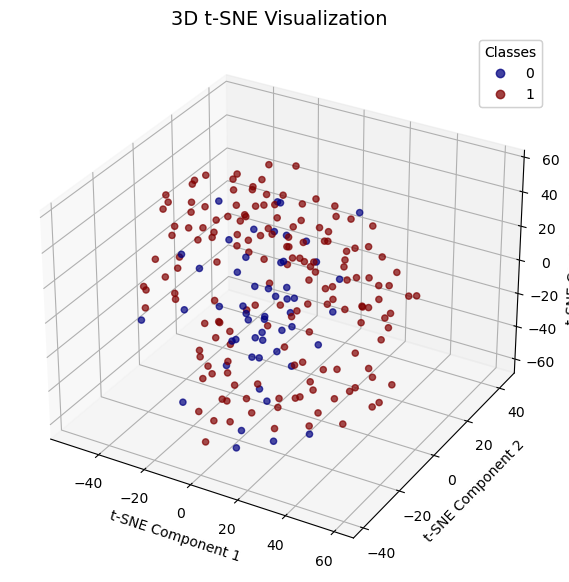

In [39]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=y_train, cmap='jet', alpha=0.7)

ax.set_title("3D t-SNE Visualization", fontsize=14)
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_zlabel("t-SNE Component 3")

legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)
plt.show()


## Classification:

### Logistic Regression

### Random Forest

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def evaluate_method(X_train, X_test, y_train, y_test, method_name):
    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    accuracy_lr = accuracy_score(y_test, y_pred_lr)

    # Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    accuracy_rf = accuracy_score(y_test, y_pred_rf)

    print(f"{method_name} - Logistic Regression Accuracy: {accuracy_lr:.4f}")
    print(f"{method_name} - Random Forest Accuracy: {accuracy_rf:.4f}")

evaluate_method(X_train_scaled, X_test_scaled, y_train, y_test, "Original Features")
evaluate_method(X_train_rfe, X_test_rfe, y_train, y_test, "RFE Features")

evaluate_method(X_train_lasso, X_test_lasso, y_train, y_test, "Lasso Features")
evaluate_method(X_train_pca, X_test_pca, y_train, y_test, "PCA Features")
evaluate_method(X_train_kpca, X_test_kpca, y_train, y_test, "KPCA Features")


Original Features - Logistic Regression Accuracy: 0.8545
Original Features - Random Forest Accuracy: 0.8545
RFE Features - Logistic Regression Accuracy: 0.8909
RFE Features - Random Forest Accuracy: 0.9091
Lasso Features - Logistic Regression Accuracy: 0.8909
Lasso Features - Random Forest Accuracy: 0.8727
PCA Features - Logistic Regression Accuracy: 0.8545
PCA Features - Random Forest Accuracy: 0.7818
KPCA Features - Logistic Regression Accuracy: 0.7636
KPCA Features - Random Forest Accuracy: 0.8364


## Feature Importance:

### Random Forest Feature Importance

### Lasso Coefficients

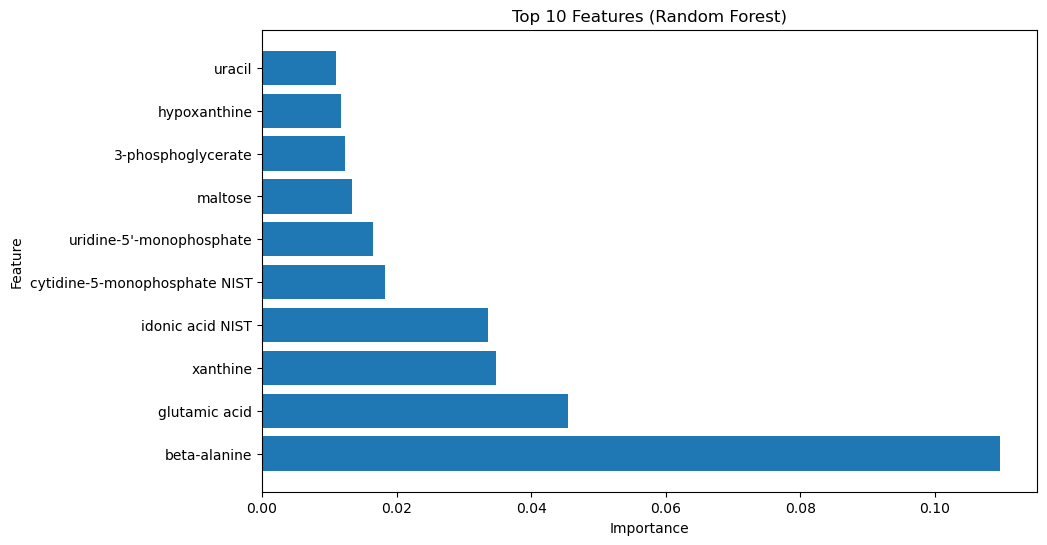

In [41]:
import matplotlib.pyplot as plt

# Train Random Forest on original features
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# Plot top 10 important features
importances = rf.feature_importances_
sorted_idx = importances.argsort()[::-1][:10]

plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx], importances[sorted_idx])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features (Random Forest)")
plt.show()

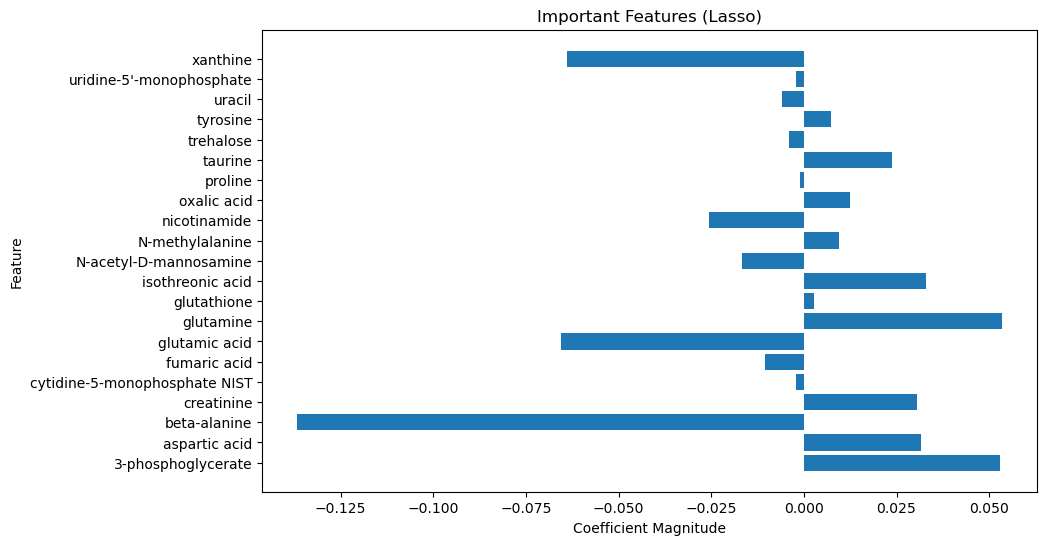

In [42]:
# Plot non-zero Lasso coefficients
plt.figure(figsize=(10, 6))
plt.barh(selected_features_lasso, lasso.coef_[lasso.coef_ != 0])
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")
plt.title("Important Features (Lasso)")
plt.show()

## plot confusion matrix

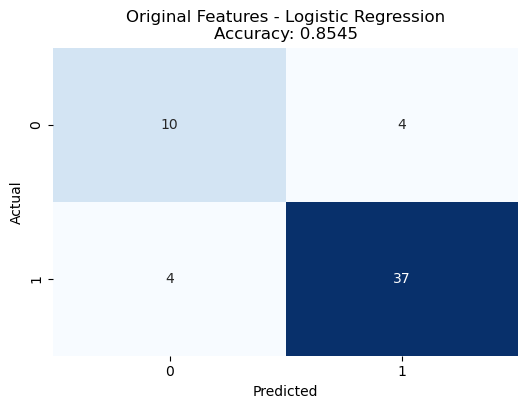

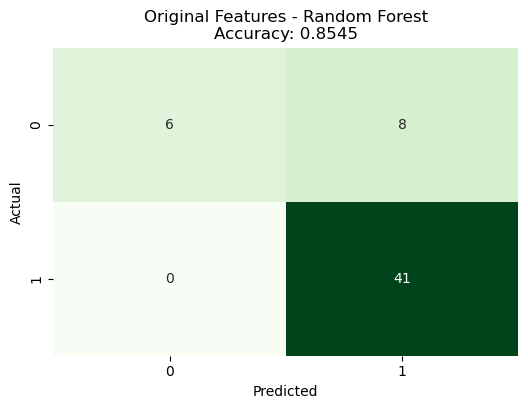

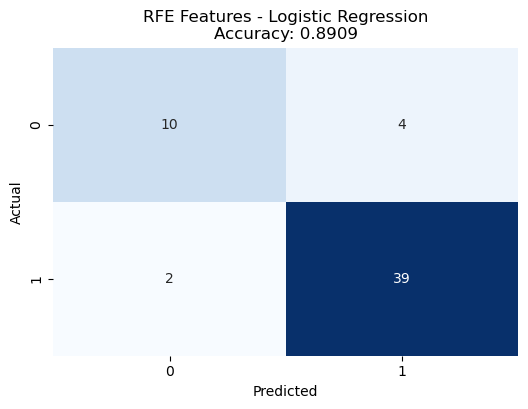

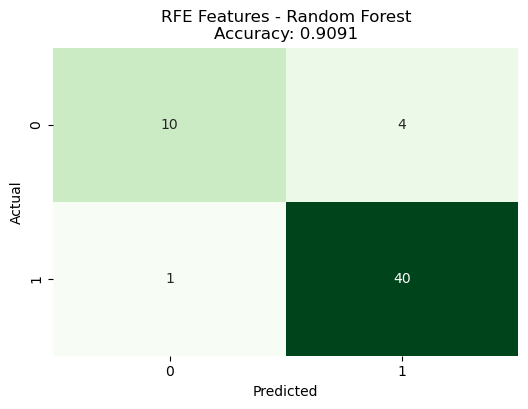

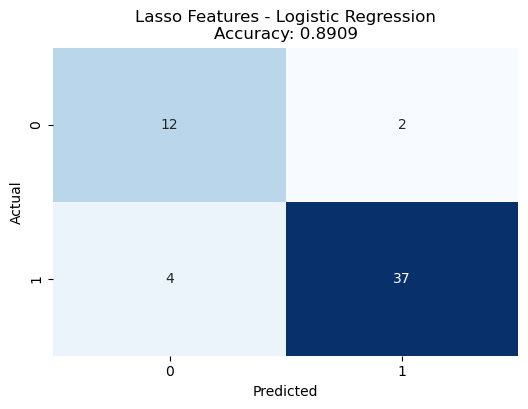

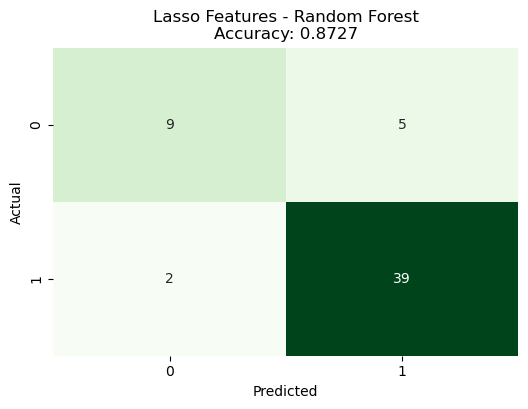

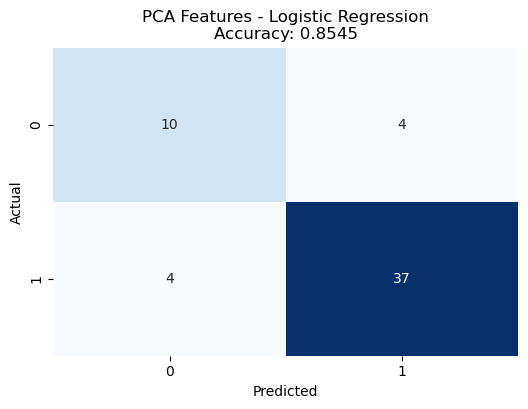

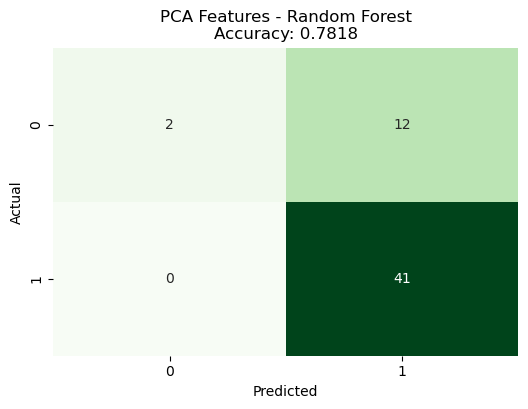

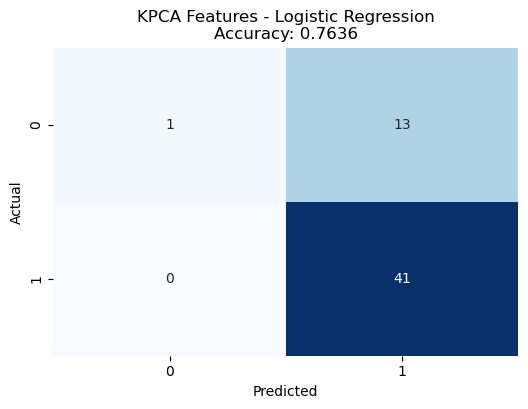

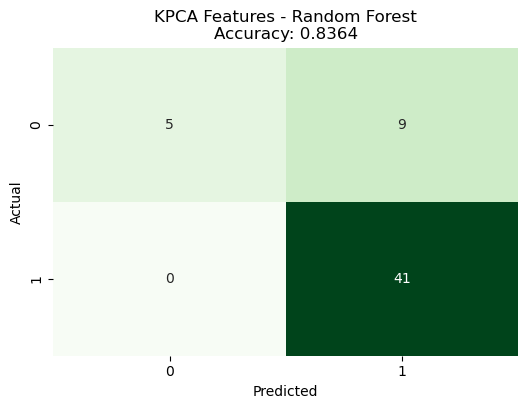

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_method(X_train, X_test, y_train, y_test, method_name):
    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    accuracy_lr = accuracy_score(y_test, y_pred_lr)

    # Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    accuracy_rf = accuracy_score(y_test, y_pred_rf)

    cm_lr = confusion_matrix(y_test, y_pred_lr)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{method_name} - Logistic Regression\nAccuracy: {accuracy_lr:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    cm_rf = confusion_matrix(y_test, y_pred_rf)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", cbar=False)
    plt.title(f"{method_name} - Random Forest\nAccuracy: {accuracy_rf:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return accuracy_lr, accuracy_rf

results = {}
results["Original Features"] = evaluate_method(X_train_scaled, X_test_scaled, y_train, y_test, "Original Features")
results["RFE Features"] = evaluate_method(X_train_rfe, X_test_rfe, y_train, y_test, "RFE Features")
results["Lasso Features"] = evaluate_method(X_train_lasso, X_test_lasso, y_train, y_test, "Lasso Features")
results["PCA Features"] = evaluate_method(X_train_pca, X_test_pca, y_train, y_test, "PCA Features")
results["KPCA Features"] = evaluate_method(X_train_kpca, X_test_kpca, y_train, y_test, "KPCA Features")
